# 六个涨跌停情绪因子：5 日因子、滚动 IC 与单因子择时

本 Notebook 保留一条可直接执行的核心研究链路：

1. 用最近 5 个交易日构造六个涨跌停情绪因子；
2. 计算因子与全 A 市值加权基准未来 1/3/5/10 日收益的时序 IC；
3. 对比全样本及当前配置窗口的滚动 IC；
4. 使用滞后一日的历史分位阈值进行单因子择时。

研究区间从 2018 年开始，回测只比较信号与同期基准，不计交易成本。


In [34]:
# ============================================================
# 导入依赖库
# ============================================================
import sys
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display


# Notebook 可能从项目根目录或当前子目录启动，统一向上定位 my_utils。
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from my_utils.fun import read_day_data
from 因子回测.alpha import add_future_return

# ============================================================
# 全局配置：研究区间、数据源、因子参数
# ============================================================

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

# 研究时间区间（2018年开始，覆盖完整牛熊周期）
START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 20)

# 数据源：米筐日线全量数据
DATA_SOURCE = "rq_stock_all_data"
# 因子滚动窗口天数（5个交易日 = 约一周）
WINDOW = 5
# 未来收益研究周期（1/3/5/10个交易日）
HORIZONS = (1, 3, 5, 10)
# 滚动 IC 窗口配置：短窗口(50日)更灵敏，长窗口(100日)更平滑
ROLLING_IC_WINDOWS = (50, 100)
# 滚动 IC 最少有效配对数比例（窗口的95%）
ROLLING_IC_MIN_VALID_RATIO = 0.95
# IC 中性区间宽度（±0.02 以内视为无方向）
IC_NEUTRAL_BAND = 0.02
# 择时阈值分位（历史 60% 分位——有区分度同时不极端稀疏）
THRESHOLD_QUANTILE = 0.60
# 扩展窗口最少预热天数（约一年交易日）
MIN_HISTORY = 252
# 涨跌停价格判断容差（close 与 limit_up/down 之差 <= 1e-6 视为涨停/跌停）
PRICE_TOLERANCE = 1e-6

# ============================================================
# 六个情绪因子的显示标签和方向
# ============================================================

# 显示用中文标签
FACTOR_LABELS = {
    "limit_up_ratio": "涨停占比",
    "limit_down_ratio": "跌停占比",
    "net_limit_ratio": "净涨停占比（涨跌停强度）",
    "limit_up_down_ratio": "涨跌停比值",
    "limit_up_next_ret": "涨停次日收益",
    "limit_down_next_ret": "跌停次日收益",
}

# 因子方向：+1 = 值越大越看多，-1 = 值越大越看空
# 跌停占比高 → 市场情绪悲观（看空），涨跌停比值高 → 多头强势（看多）
FACTOR_DIRECTIONS = {
    "limit_up_ratio": 1,
    "limit_down_ratio": 1,  # 跌停占比高=看空
    "net_limit_ratio": 1,
    "limit_up_down_ratio": 1,
    "limit_up_next_ret": 1,
    "limit_down_next_ret": 1,  # 跌停次日收益高=悲观情绪延续
}

# 因子列名列（用于循环遍历）
FACTOR_COLUMNS = list(FACTOR_LABELS)
# ============================================================
# 新增：导入择时引擎和基准加载器
# ============================================================
from 因子回测.涨跌停情绪因子.timing_engine import (
    build_value_weighted_benchmark, compute_threshold,
    annualized_metrics, run_timing, summarize_timing,
    plot_timing_nav_comparison,
    run_multi_benchmark_timing, plot_multi_benchmark_summary,
)
from 因子回测.涨跌停情绪因子.benchmark_loader import load_benchmark, list_available_benchmarks


## 1. 构造六个情绪因子与市场基准

比率因子使用事件发生日数据；涨跌停次日收益按收益实际兑现日进入滚动窗口。
基准使用前一交易日总市值加权，确保因子、基准和未来收益均不读取当时未知的数据。


In [35]:
# ============================================================
# prepare_stock_daily：清洗日线数据，对齐涨停标记与基准权重
# ============================================================
def prepare_stock_daily(
    daily_raw: pl.DataFrame,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    清洗逐股日线，对齐交易日，筛选因子股票池，标记涨停/跌停。

    内部完成沪深 A 股筛选（排除 ST、停牌、价格异常），返回已过滤的日线数据。
    下游函数接收的 prepared 已经是合格股票，无需再判断 eligible。

    Parameters
    ----------
    daily_raw : pl.DataFrame
        原始日线，含 code, trading_date, close, pre_close, pct, limit_up,
        limit_down, is_st, is_suspended, total_mv。

    Returns
    -------
    tuple[pl.DataFrame, pl.DataFrame]
        (prepared, calendar)
        - prepared: 仅含因子合格股票的清洗对齐数据
        - calendar: 全市场交易日历
    """
    # 1. 选择需要的基础字段，按股票+日期排序
    columns = [
        "code", "trading_date", "close", "pre_close", "pct", "limit_up",
        "limit_down", "is_st", "is_suspended", "total_mv",
    ]
    data = (
        daily_raw.select(columns)
        .with_columns(pl.col("trading_date").cast(pl.Date))
        .sort(["code", "trading_date"])
    )

    # 2. 生成全市场交易日历（仅保留 next_market_date 供次日收益校验用）
    calendar = (
        data.select("trading_date")
        .unique()
        .sort("trading_date")
        .with_columns(
            pl.col("trading_date").shift(-1).alias("next_market_date"),
        )
    )

    # 3. 按股票分组获得前日市值和次一收盘价
    data = data.join(calendar, on="trading_date", how="left").with_columns(
        pl.col("total_mv").shift(1).over("code").alias("previous_total_mv"),
        pl.col("trading_date").shift(-1).over("code").alias("next_stock_date"),
        pl.col("close").shift(-1).over("code").alias("next_close"),
        # 代码第6位（首位数字）：6=沪市，0=深市主板，3=创业板
        pl.col("code").str.slice(5, 1).alias("code_prefix"),
    )

    # 4. 因子股票池条件（内部使用，不输出为列）
    eligible = (
        pl.col("code_prefix").is_in(["6", "0", "3"])
        & ~pl.col("is_st").fill_null(False).cast(pl.Boolean)
        & ~pl.col("is_suspended").fill_null(False).cast(pl.Boolean)
        & (pl.col("close") > 0)
        & (pl.col("pre_close") > 0)
        & (pl.col("limit_up") > 0)
        & (pl.col("limit_down") > 0)
    )

    # 5. 标记涨停/跌停（只对合格股票标记，避免北交所等干扰）
    data = data.with_columns(
        (
            eligible
            & ((pl.col("close") - pl.col("limit_up")).abs() <= PRICE_TOLERANCE)
        ).alias("is_limit_up"),
        (
            eligible
            & ((pl.col("close") - pl.col("limit_down")).abs() <= PRICE_TOLERANCE)
        ).alias("is_limit_down"),
    )

    # 6. 事件次日收益：只在该股票下一日恰为市场下一交易日时才有效
    #    防止停牌造成的跨期收益被错误归到因子日期
    data = data.with_columns(
        pl.when(
            (pl.col("next_stock_date") == pl.col("next_market_date"))
            & (pl.col("next_close") > 0)
        )
        .then(pl.col("next_close") / pl.col("close") - 1)
        .otherwise(None)
        .alias("event_next_ret"),
    )

    # 7. 基准权重：前一交易日总市值
    #    注：停牌时前日市值仍可用于加权（总市值非隔夜跳变）
    data = data.with_columns(
        pl.when(pl.col("previous_total_mv") > 0)
        .then(pl.col("previous_total_mv"))
        .otherwise(None)
        .alias("benchmark_weight"),
    )

    # 8. 过滤：只返回合格股票（下游无需再筛选）
    data = data.filter(eligible)
    return data, calendar


# ============================================================
# build_daily_sentiment_factors：构造六个涨跌停情绪因子
# ============================================================
def build_daily_sentiment_factors(
    prepared: pl.DataFrame,
    calendar: pl.DataFrame,
    window: int = 5,
) -> pl.DataFrame:
    """
    一次 group_by 构造六个涨跌停情绪因子。

    四个比率因子（滚动窗口内累计）：
      - limit_up_ratio: 涨停占比 = 5日涨停数 / 5日最大合格股票数
      - limit_down_ratio: 跌停占比
      - net_limit_ratio: 净涨停占比
      - limit_up_down_ratio: 涨跌停比值（跌停数为0时返回Null）

    两个收益因子（滚动窗口内事件加权平均）：
      - limit_up_next_ret: 涨停次日收益均值
      - limit_down_next_ret: 跌停次日收益均值

    收益列通过 shift(1) 对齐到兑现日（t 日涨停的次日在 t+1），
    替代原版按 next_market_date 分组再 join 的做法，数学等价。
    """
    # 1. 一次聚合：计数 + 次日收益总和
    daily = (
        prepared.group_by("trading_date")
        .agg(
            n_stock=pl.col("code").n_unique(),
            n_up=pl.col("is_limit_up").cast(pl.Int64).sum(),
            n_down=pl.col("is_limit_down").cast(pl.Int64).sum(),
            up_ret=pl.col("event_next_ret").filter(pl.col("is_limit_up")).sum(),
            down_ret=pl.col("event_next_ret").filter(pl.col("is_limit_down")).sum(),
        )
        .sort("trading_date")
    )

    # 2. 对齐到全市场日历，无事件日补 0
    result = (
        calendar.select("trading_date")
        .join(daily, on="trading_date", how="left")
        .sort("trading_date")
        .with_columns(pl.col("n_stock", "n_up", "n_down", "up_ret", "down_ret").fill_null(0))
    )

    # 3. 滚动窗口 → 六个因子（select 里直出，不保留中间列）
    denom = pl.when(pl.col("n_stock").rolling_max(window, min_periods=window) > 0) \
              .then(pl.col("n_stock").rolling_max(window, min_periods=window)).otherwise(None)

    return result.select(
        "trading_date",
        limit_up_ratio=pl.col("n_up").rolling_sum(window, min_periods=window) / denom,
        limit_down_ratio=pl.col("n_down").rolling_sum(window, min_periods=window) / denom,
        net_limit_ratio=(
            pl.col("n_up").rolling_sum(window, min_periods=window)
            - pl.col("n_down").rolling_sum(window, min_periods=window)
        ) / denom,
        limit_up_down_ratio=pl.when(pl.col("n_down").rolling_sum(window, min_periods=window) > 0)
            .then(pl.col("n_up").rolling_sum(window, min_periods=window)
                  / pl.col("n_down").rolling_sum(window, min_periods=window))
            .otherwise(None),
        # 收益 shift(1)：t 日涨停确认收益在 t+1，因子 t 只能看到 t-1 及以前的收益
        limit_up_next_ret=(
            pl.col("up_ret").shift(1).rolling_sum(window, min_periods=window)
            / pl.col("n_up").shift(1).rolling_sum(window, min_periods=window)
        ),
        limit_down_next_ret=(
            pl.col("down_ret").shift(1).rolling_sum(window, min_periods=window)
            / pl.col("n_down").shift(1).rolling_sum(window, min_periods=window)
        ),
    )




In [36]:
# ============================================================
# 执行数据管线：读取原始日线 → 清洗对齐 → 构造因子 → 基准 → 未来收益
# ============================================================

# 1. 从本地数据源读取原始日线数据（指定字段减少内存）
daily_fields = [
    "code", "trading_date", "close", "pre_close", "pct", "limit_up",
    "limit_down", "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE,
    END_DATE,
    fields=daily_fields,
    file_path=DATA_SOURCE,
).sort(["code", "trading_date"])

# 2. 清洗对齐：标记涨停/跌停、计算基准权重、对齐交易日
prepared_daily, trading_calendar = prepare_stock_daily(daily_raw)

# 3. 构造六个情绪因子：5日滚动窗口的涨停/跌停占比和次日收益均值
factor_daily = build_daily_sentiment_factors(
    prepared_daily, trading_calendar, window=WINDOW
)

# 4. 构造全A市值加权基准日收益
market_daily = build_value_weighted_benchmark(prepared_daily, trading_calendar)

# 5. 添加未来 1/3/5/10 日累计收益（用于后续 IC 和择时分析）
market_with_forward = add_future_return(
    market_daily, ret_col="market_daily_ret", horizons=HORIZONS
)

# 6. 合并因子表与基准/未来收益表，按 trading_date inner join
research_data = factor_daily.to_pandas()
research_data["trading_date"] = pd.to_datetime(research_data["trading_date"])
research_data = (
    research_data.merge(market_with_forward, on="trading_date", how="inner")
    .sort_values("trading_date")
    .reset_index(drop=True)
)

# 查看尾部数据确认管线正确
display(research_data[["trading_date", *FACTOR_COLUMNS]].tail())

,trading_date,limit_up_ratio,limit_down_ratio,net_limit_ratio,limit_up_down_ratio,limit_up_next_ret,limit_down_next_ret
2067,2026-07-14,0.06396631,0.05434129,0.00962503,1.17712177,-0.00206309,-0.01825526
2068,2026-07-15,0.06877882,0.05273712,0.01604171,1.30418251,0.00017216,-0.01681319
2069,2026-07-16,0.06196110,0.05734911,0.00461199,1.08041958,0.00297821,-0.01836830
2070,2026-07-17,0.04890258,0.09472468,-0.04582210,0.51626016,0.00035637,-0.02588803
2071,2026-07-20,0.05390836,0.10512129,-0.05121294,0.51282051,0.01169661,-0.04802743


## 3. 历史阈值与单因子择时

每个交易日的阈值只使用前一日及更早的历史数据。六项因子从阈值共同可用日开始，
预热期结束后，信号触发即开仓：决策日收盘观察因子值，仓位从下一交易日开始，
持有 horizon 个交易日；若在持有期内再次触发，持仓自动延长至新触发日 + horizon，
实现"信号续期"。信号消失后不提前平仓，持有满 horizon 个交易日到期。

基准始终满仓并使用与策略完全相同的日期。图中结果不计交易成本、滑点和指数复制误差。


In [37]:
# ============================================================
# 全 A 单基准择时（函数已迁移到 timing_engine.py）
# ============================================================

timing_input = compute_threshold(
    research_data, lower_quantile=0.65, upper_quantile=1, min_history=MIN_HISTORY,
)

for factor in FACTOR_COLUMNS:
    timing_input[f"signal_{factor}"] = (
        (timing_input[factor] >= timing_input[f"lower_{factor}"])
        & (timing_input[factor] <= timing_input[f"upper_{factor}"])
    ).astype(float)

threshold_columns = [f"lower_{factor}" for factor in FACTOR_COLUMNS]
common_valid = timing_input[threshold_columns].notna().all(axis=1)
common_anchor = pd.Timestamp(timing_input.loc[common_valid.idxmax(), "trading_date"])

timing_daily = {}
timing_summary_rows = []
for factor in FACTOR_COLUMNS:
    for horizon in HORIZONS:
        daily_detail, block_detail = run_timing(
            timing_input, signal_column=f"signal_{factor}",
            horizon=horizon, anchor_date=common_anchor,
        )
        timing_daily[(factor, horizon)] = daily_detail
        timing_summary_rows.append(
            summarize_timing(daily_detail, block_detail, factor=factor, horizon=horizon, factor_labels=FACTOR_LABELS)
        )

timing_summary = pd.DataFrame(timing_summary_rows)
timing_summary["annual_excess_return"] = timing_summary["annual_return"] - timing_summary["benchmark_annual_return"]

timing_display = timing_summary[
    ["factor_label", "horizon", "rebalance_count", "holding_ratio", "holding_win_rate",
     "timing_hit_rate", "annual_return", "benchmark_annual_return", "annual_excess_return",
     "max_drawdown", "sharpe", "final_nav", "benchmark_final_nav", "relative_final_nav"]
].rename(columns={
    "factor_label": "因子", "horizon": "持有日数", "rebalance_count": "持仓段数",
    "holding_ratio": "持仓比例", "holding_win_rate": "持仓胜率",
    "timing_hit_rate": "择时命中率", "annual_return": "策略年化",
    "benchmark_annual_return": "基准年化", "annual_excess_return": "年化差",
    "max_drawdown": "策略最大回撤", "sharpe": "策略夏普",
    "final_nav": "策略期末净值", "benchmark_final_nav": "基准期末净值",
    "relative_final_nav": "相对期末净值",
})
display(timing_display.style.format({
    "持仓比例": "{:.2%}", "持仓胜率": "{:.2%}", "择时命中率": "{:.2%}",
    "策略年化": "{:.2%}", "基准年化": "{:.2%}", "年化差": "{:+.2%}",
    "策略最大回撤": "{:.2%}", "策略夏普": "{:.2f}",
    "策略期末净值": "{:.3f}", "基准期末净值": "{:.3f}",
    "相对期末净值": "{:+.2%}",
}))


In [38]:
# ============================================================
# 多基准择时对比
# ============================================================

BENCHMARKS = list_available_benchmarks()
BENCHMARK_LABELS = {
    "all_a_value_weight": "全A市值加权",
    "zz500": "中证500", "zz1000": "中证1000", "zz2000": "中证2000",
}

multi_results = run_multi_benchmark_timing(
    factor_daily=factor_daily, benchmarks=BENCHMARKS,
    prepared_daily=prepared_daily, calendar=trading_calendar,
    start_date=START_DATE, end_date=END_DATE, horizons=HORIZONS,
    factor_columns=FACTOR_COLUMNS, factor_labels=FACTOR_LABELS,
)

summary = multi_results["summary"]
display(summary.style.format({
    "holding_ratio": "{:.2%}", "annual_return": "{:.2%}",
    "benchmark_annual_return": "{:.2%}", "annual_excess_return": "{:+.2%}",
    "max_drawdown": "{:.2%}", "sharpe": "{:.2f}",
    "final_nav": "{:.3f}", "benchmark_final_nav": "{:.3f}",
    "relative_final_nav": "{:+.2%}",
}))


,因子,持有日数,持仓段数,持仓比例,持仓胜率,择时命中率,策略年化,基准年化,年化差,策略最大回撤,策略夏普,策略期末净值,基准期末净值,相对期末净值
0,涨停占比,1,53,27.12%,60.38%,54.95%,6.89%,8.67%,-1.79%,-16.39%,0.64,1.615,1.820,-11.24%
1,涨停占比,3,51,34.07%,50.98%,51.02%,8.21%,8.67%,-0.47%,-16.30%,0.69,1.764,1.820,-3.05%
2,涨停占比,5,40,39.42%,62.50%,59.74%,10.25%,8.67%,+1.57%,-16.95%,0.79,2.018,1.820,+10.90%
3,涨停占比,10,29,48.68%,65.52%,52.63%,7.02%,8.67%,-1.66%,-20.64%,0.53,1.629,1.820,-10.48%
4,跌停占比,1,72,25.41%,66.67%,56.43%,9.66%,8.67%,+0.98%,-16.40%,0.81,1.942,1.820,+6.69%
5,跌停占比,3,66,33.41%,72.73%,64.62%,11.07%,8.67%,+2.39%,-18.55%,0.86,2.129,1.820,+16.96%
6,跌停占比,5,62,40.46%,67.74%,64.66%,10.18%,8.67%,+1.51%,-19.08%,0.77,2.010,1.820,+10.42%
7,跌停占比,10,35,54.19%,57.14%,50.00%,4.99%,8.67%,-3.69%,-22.99%,0.40,1.420,1.820,-21.99%
8,净涨停占比（涨跌停强度）,1,73,31.37%,53.42%,47.77%,2.35%,8.67%,-6.33%,-26.66%,0.27,1.182,1.820,-35.07%
9,净涨停占比（涨跌停强度）,3,74,41.57%,52.70%,47.48%,5.78%,8.67%,-2.90%,-18.90%,0.49,1.498,1.820,-17.67%


### 3.1 单因子择时与基准净值

- 黑色虚线是同一组日期上的全 A 市值加权基准，红线是单因子择时净值。
- 每个因子单独展示一张 2×2 图，对应 1、3、5、10 日持有周期。
- 子图标题同时给出实际持仓比例，便于区分"少持仓降低波动"和真正改善收益路径。
- 这些曲线与上方汇总表使用完全相同的逐日收益，不额外做平滑或抽样。


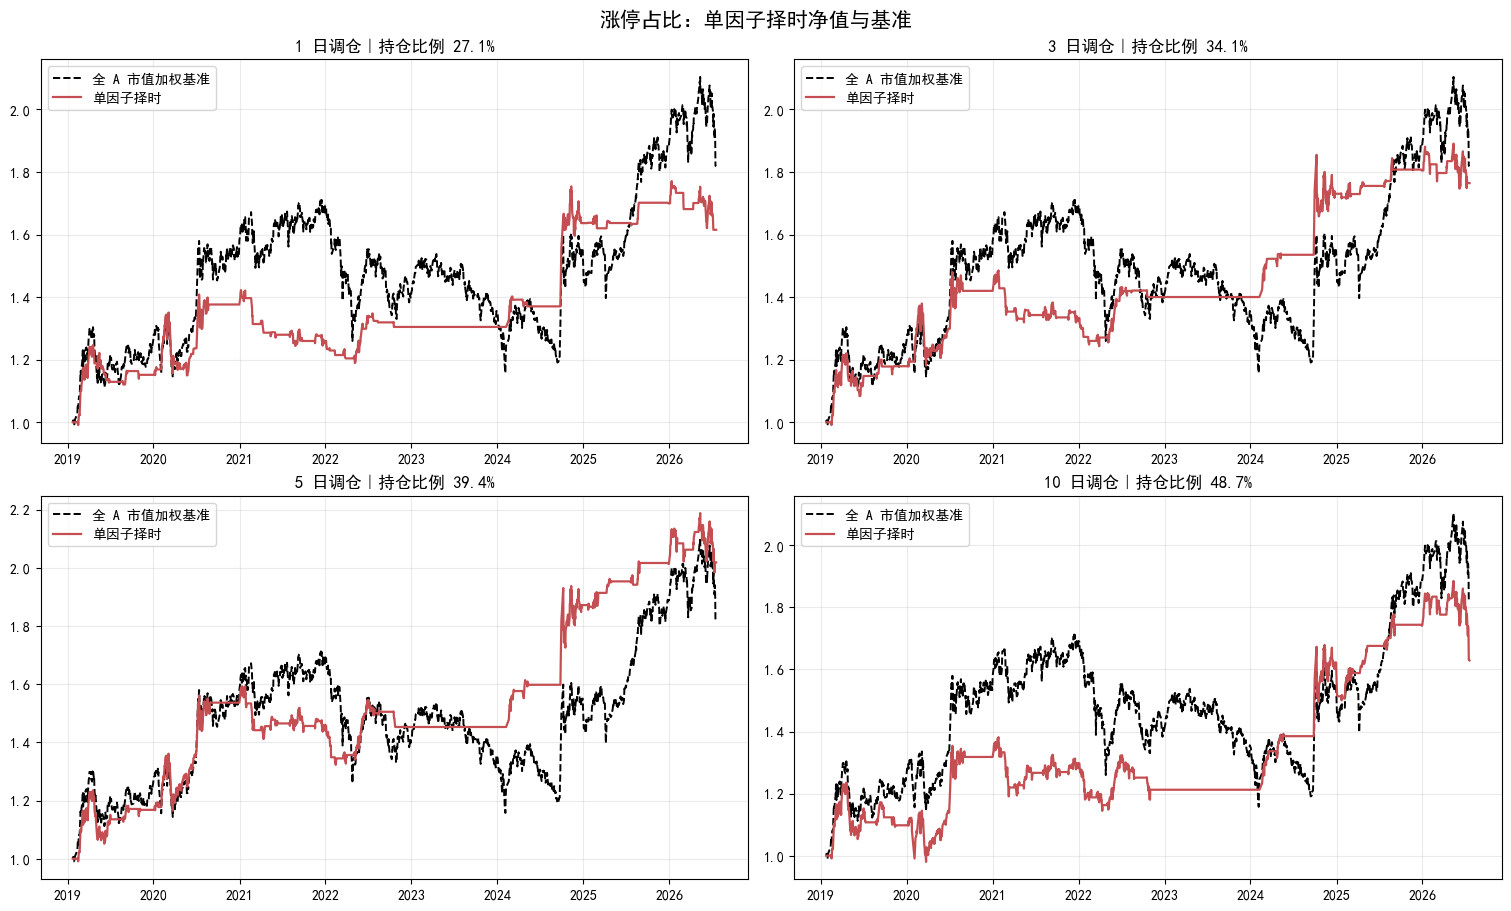

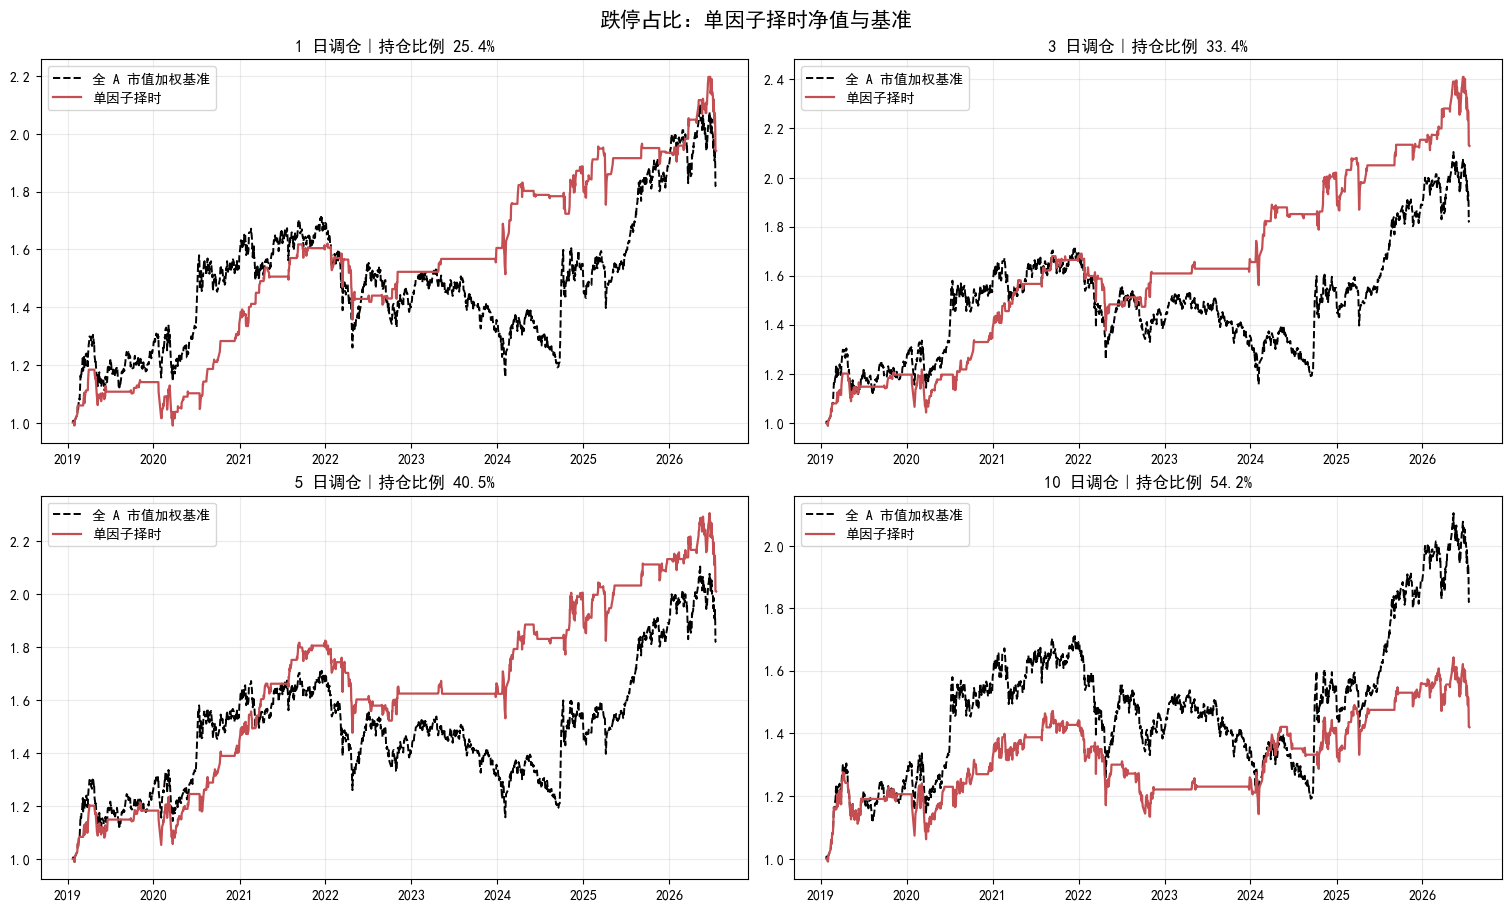

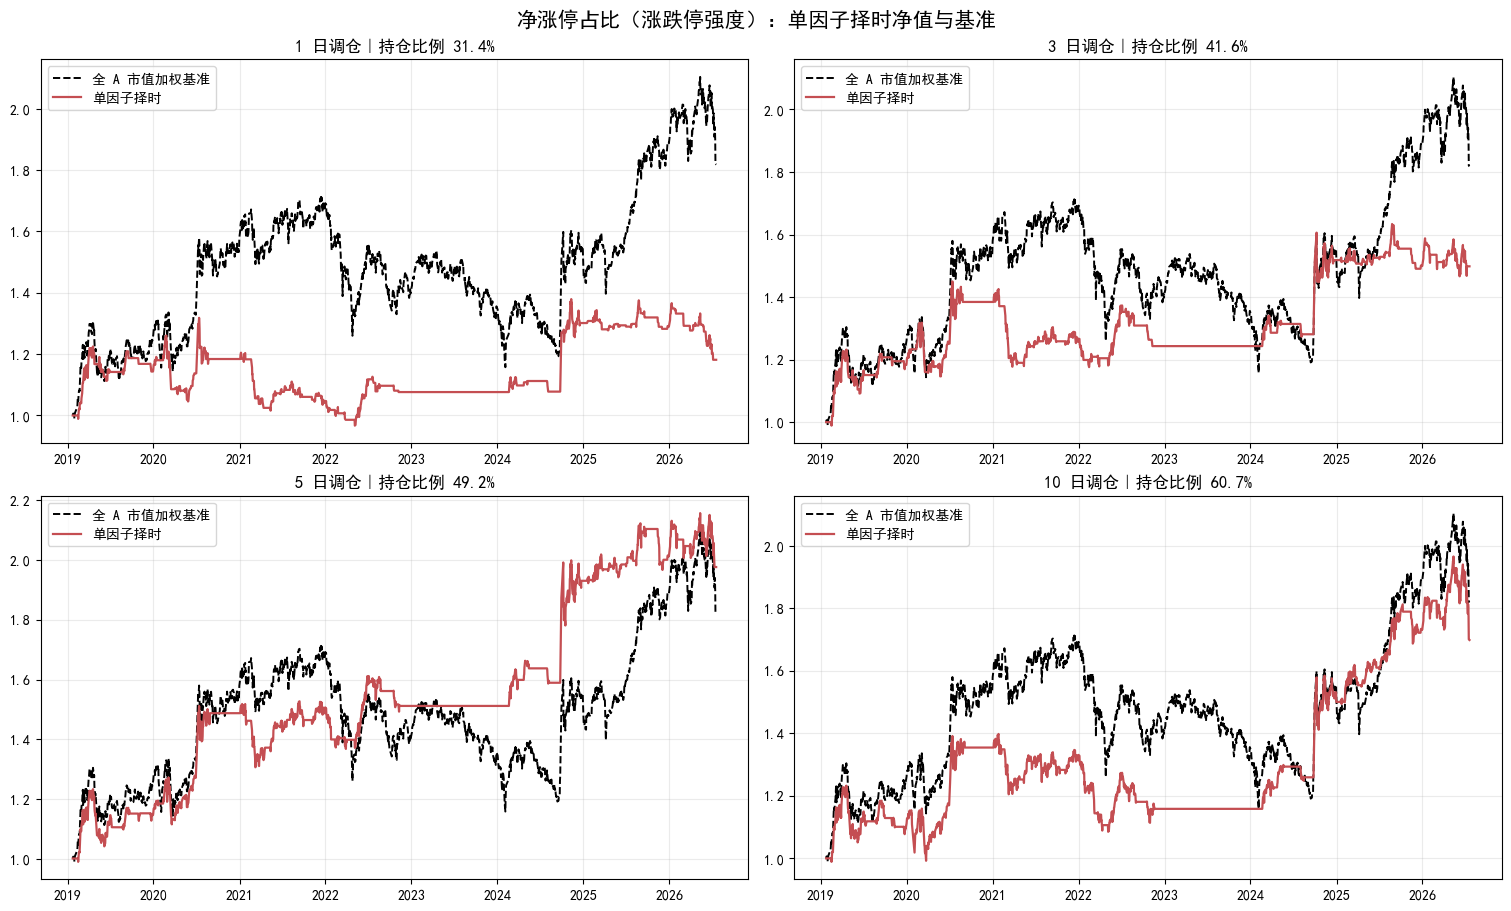

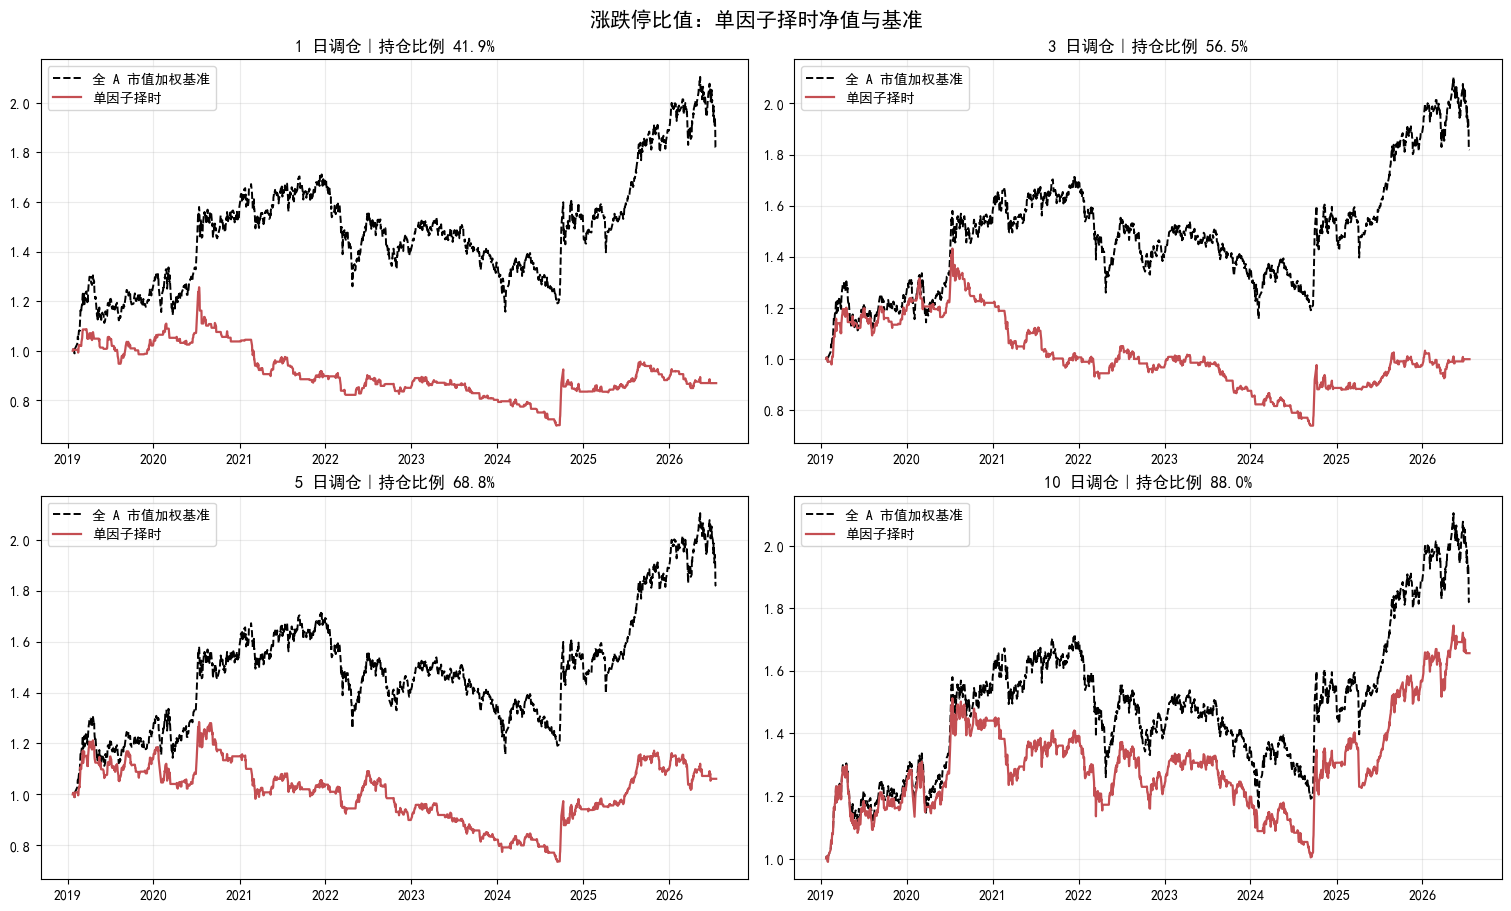

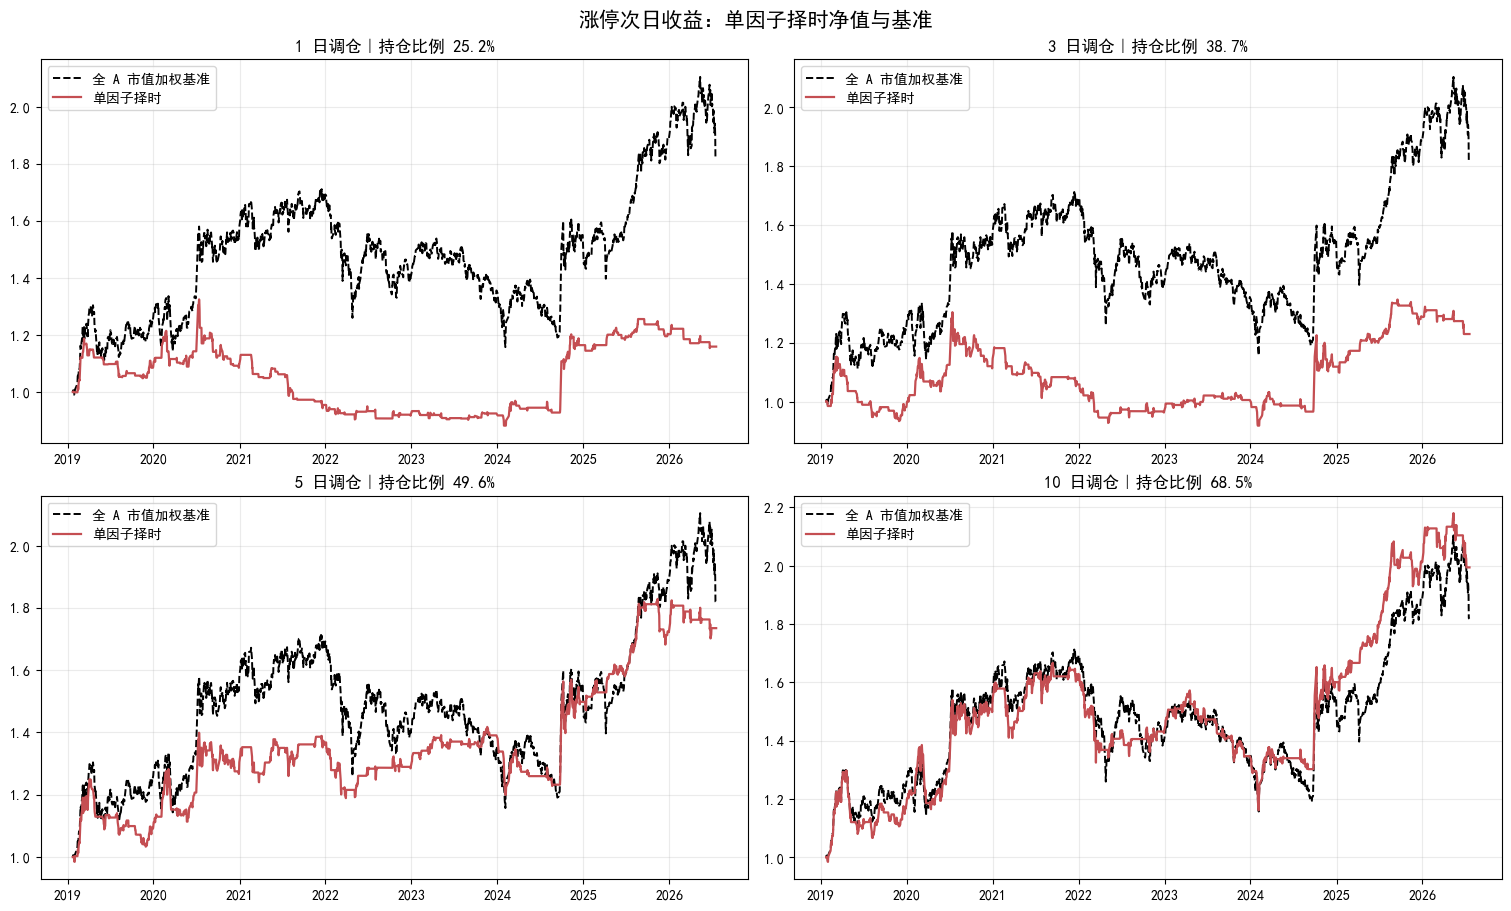

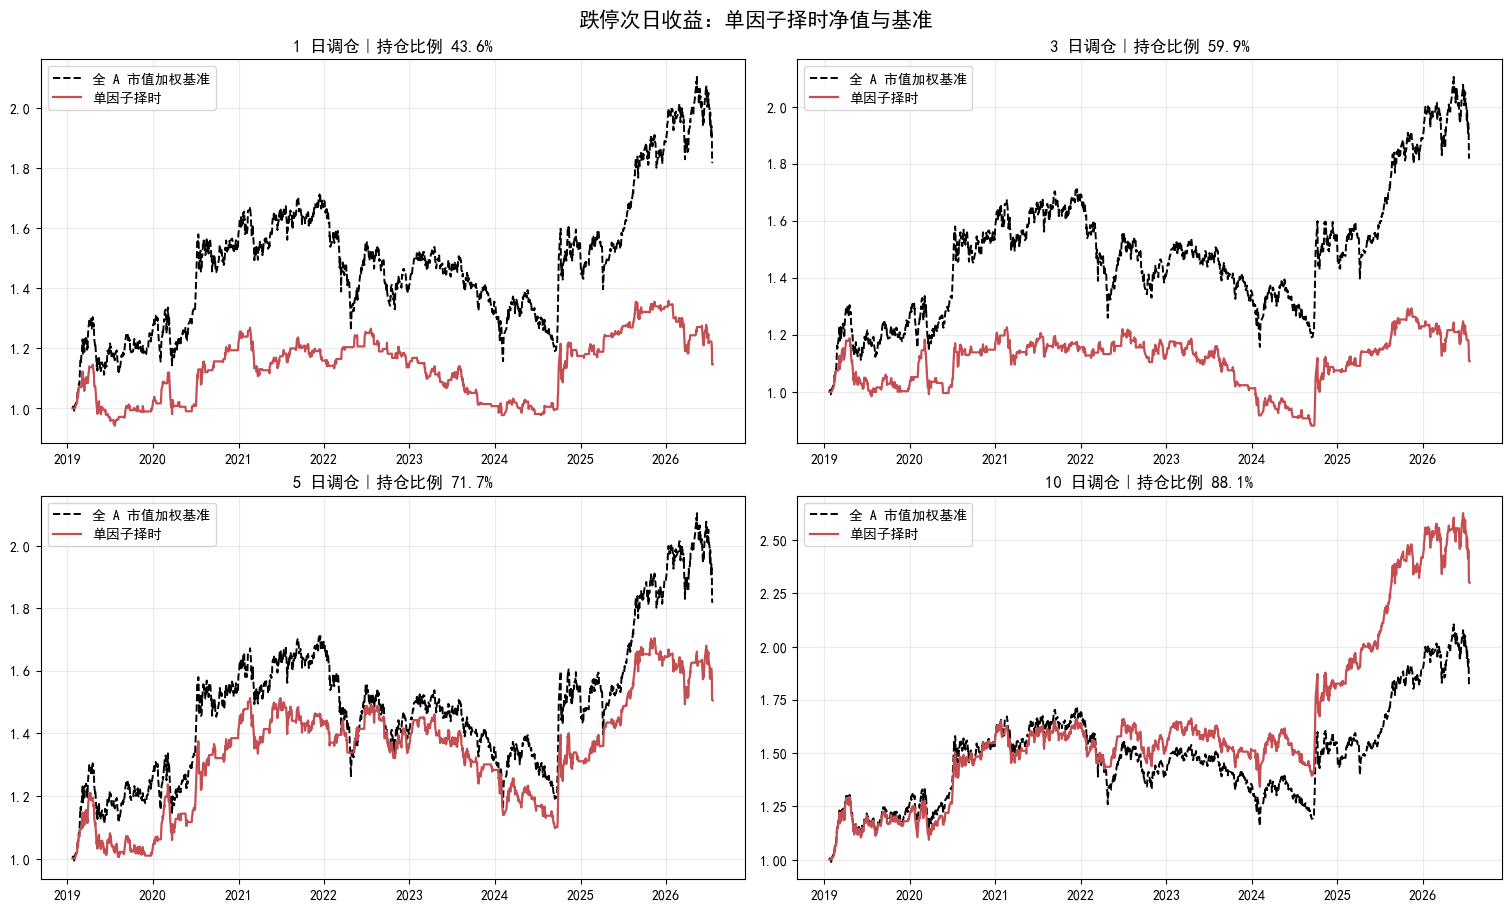

In [39]:
# ============================================================
# 多基准择时净值对比图
# ============================================================

plot_multi_benchmark_summary(
    multi_results, factor_columns=FACTOR_COLUMNS,
    factor_labels=FACTOR_LABELS, horizons=HORIZONS,
    benchmarks=BENCHMARKS, benchmark_labels=BENCHMARK_LABELS,
)


## 2. 基础 IC 与滚动 IC

这里计算的是市场时序 IC，而不是截面选股 IC。原始 IC 展示实际相关方向；
方向调整 IC 仅将负向的“跌停占比”乘以 -1，方便六个指标统一按“越大越看多”比较。

全样本 IC 用于观察长期平均关系，滚动 IC 用于检查这种关系是否随市场阶段变化。
两者都是描述统计，不直接作为当日交易信号。


In [40]:
# ============================================================
# analyze_ic：计算各因子与未来收益的时序 IC
# ============================================================
def analyze_ic(
    data: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    horizons: tuple[int, ...] = HORIZONS,
    factor_directions: dict[str, int] = FACTOR_DIRECTIONS,
) -> pd.DataFrame:
    """
    计算各因子与不同周期未来收益的 Pearson、Spearman 时序 IC。

    这里计算的是市场时序 IC（单列因子 vs 单列未来收益），而不是截面选股 IC。
    
    - Pearson IC: 线性相关系数，衡量因子与未来收益的线性关系
    - Spearman IC: 秩相关系数，衡量因子与未来收益的排序一致性
    - 方向调整 IC: Pearson IC × 因子方向（方便六个指标统一按"越大越看多"比较）

    Parameters
    ----------
    data : pd.DataFrame
        含因子列和 future_market_daily_ret_{n}d 列的研究数据。
    factor_columns : list[str]
        因子列名列表。
    horizons : tuple[int, ...]
        未来收益周期列表。
    factor_directions : dict[str, int]
        因子方向字典：+1=正向，-1=反向。

    Returns
    -------
    pd.DataFrame
        每行一个(因子, 周期)组合的 IC 指标。
    """
    rows = []
    for factor in factor_columns:
        # 因子方向：用于计算方向调整 IC
        direction = factor_directions.get(factor, 1)
        for horizon in horizons:
            target = f"future_market_daily_ret_{horizon}d"
            # 剔除 inf/NaN 后再计算相关性
            sample = (
                data[[factor, target]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )
            # Pearson 线性相关
            pearson_ic = sample[factor].corr(sample[target], method="pearson")
            # Spearman 秩相关（稳健性检验）
            spearman_ic = sample[factor].corr(sample[target], method="spearman")
            rows.append(
                {
                    "factor": factor,
                    "factor_label": FACTOR_LABELS.get(factor, factor),
                    "horizon": horizon,
                    "n_obs": len(sample),
                    "pearson_ic": pearson_ic,
                    "spearman_ic": spearman_ic,
                    "directional_pearson_ic": pearson_ic * direction,
                }
            )
    return pd.DataFrame(rows)


# ============================================================
# report_ic_summary：展示 IC 汇总表 + 热力图
# ============================================================
def report_ic_summary(
    summary: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    horizons: tuple[int, ...] = HORIZONS,
) -> None:
    """
    展示 IC 汇总表格，并绘制原始及方向调整后的 Pearson IC 热力图。

    热力图左侧为原始 IC（反映真实相关方向），右侧为方向调整 IC（方便统一比较）。
    颜色深浅映射 IC 绝对值大小，红色=正，蓝色=负。

    Parameters
    ----------
    summary : pd.DataFrame
        analyze_ic 的输出 DataFrame。
    factor_columns : list[str]
        因子列名列表（决定显示顺序）。
    horizons : tuple[int, ...]
        未来收益周期列表（决定 x 轴顺序）。
    """
    # 1. 展示汇总数字表
    display_table = summary[
        [
            "factor_label", "horizon", "n_obs", "pearson_ic",
            "spearman_ic", "directional_pearson_ic",
        ]
    ].rename(
        columns={
            "factor_label": "因子",
            "horizon": "未来日数",
            "n_obs": "样本数",
            "pearson_ic": "Pearson IC",
            "spearman_ic": "Spearman IC",
            "directional_pearson_ic": "方向调整 IC",
        }
    )
    display(
        display_table.style.format(
            {
                "Pearson IC": "{:.4f}",
                "Spearman IC": "{:.4f}",
                "方向调整 IC": "{:.4f}",
            }
        )
    )

    # 2. 绘制热力图：原始 IC（左）和方向调整 IC（右）
    factor_order = [FACTOR_LABELS.get(factor, factor) for factor in factor_columns]
    heatmap_specs = (
        ("pearson_ic", "原始 Pearson IC"),
        ("directional_pearson_ic", "方向调整 Pearson IC"),
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
    for axis, (metric, title) in zip(axes, heatmap_specs):
        # pivot 成 6因子 × 4周期 的矩阵
        matrix = (
            summary.pivot(index="factor_label", columns="horizon", values=metric)
            .reindex(index=factor_order, columns=horizons)
        )
        values = matrix.to_numpy(dtype=float)
        # 自动确定色阶范围，避免极端值冲淡中间色调
        finite_values = np.abs(values[np.isfinite(values)])
        limit = max(0.05, float(finite_values.max())) if finite_values.size else 0.05
        image = axis.imshow(
            values, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit
        )
        # 标记坐标轴
        axis.set_xticks(
            range(len(horizons)), [f"{horizon}日" for horizon in horizons]
        )
        axis.set_yticks(range(len(factor_order)), factor_order)
        axis.set_title(title)
        # 在每个格子中标注 IC 数值
        for row_index, row in enumerate(values):
            for column_index, value in enumerate(row):
                label = f"{value:.3f}" if np.isfinite(value) else "—"
                axis.text(
                    column_index, row_index, label, ha="center", va="center"
                )
        fig.colorbar(image, ax=axis, shrink=0.82)
    plt.show()


# ============================================================
# format_optional_date：格式化可选日期（用于 IC 汇总表显示）
# ============================================================
def format_optional_date(value: object) -> str:
    """
    格式化可选日期；缺失日期在汇总表中显示为破折号。
    
    用于滚动 IC 汇总表的最新可用日列，若窗口尚未完整则显示 —。
    """
    if pd.isna(value):
        return "—"
    return pd.Timestamp(value).strftime("%Y-%m-%d")


# ============================================================
# compute_rolling_ic：计算滚动 Pearson IC
# ============================================================
def compute_rolling_ic(
    data: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    horizons: tuple[int, ...] = HORIZONS,
    windows: tuple[int, ...] = ROLLING_IC_WINDOWS,
    min_valid_ratio: float = ROLLING_IC_MIN_VALID_RATIO,
) -> pd.DataFrame:
    """
    计算滚动 Pearson IC，并同时记录窗口结束日和真实可用日。

    因子日期 t 对应的未来 n 日收益要到 t+n 收盘后才完全兑现，因此图表必须
    使用 available_date 作横轴；factor_window_end_date 仅用于追溯原窗口。

    窗口跨度固定为交易日数，完整预热后允许少量缺失；有效配对数必须达到
    ceil(window * min_valid_ratio) 才输出 IC，并随结果记录实际样本量。

    Parameters
    ----------
    data : pd.DataFrame
        含因子列和 future_market_daily_ret_{n}d 列的研究数据。
    factor_columns : list[str]
        因子列名列表。
    horizons : tuple[int, ...]
        未来收益周期列表。
    windows : tuple[int, ...]
        滚动窗口列表，每个窗口独立输出一条 IC 序列。
    min_valid_ratio : float
        窗口内最少有效配对比例（默认 0.95 = 95%）。

    Returns
    -------
    pd.DataFrame
        长格式 DataFrame，每行对应一个(因子, 周期, 窗口, 交易日)的滚动 IC 值。
    """
    # 参数校验
    if not 0 < min_valid_ratio <= 1:
        raise ValueError("min_valid_ratio 必须在 (0, 1] 范围内")

    ordered = data.copy().sort_values("trading_date").reset_index(drop=True)
    rows = []
    
    # 遍历因子 × 周期 × 窗口，生成每条 IC 序列
    for factor in factor_columns:
        for horizon in horizons:
            target = f"future_market_daily_ret_{horizon}d"
            # 剔除 inf 避免相关计算异常
            factor_values = ordered[factor].replace([np.inf, -np.inf], np.nan)
            target_values = ordered[target].replace([np.inf, -np.inf], np.nan)
            # 有效配对：因子值和目标收益均非空
            pair_is_valid = factor_values.notna() & target_values.notna()
            
            for window in windows:
                # 最少需要的有效配对数
                min_required_obs = int(np.ceil(window * min_valid_ratio))
                # 滚动窗口内的有效配对计数
                rolling_n_obs = (
                    pair_is_valid.rolling(window, min_periods=1).sum().astype(int)
                )
                # 滚动 Pearson 相关系数
                rolling_ic = factor_values.rolling(
                    window, min_periods=min_required_obs
                ).corr(target_values)
                
                # 前 window-1 天属于预热期，不输出 IC
                # 同时要求有效配对数 >= 最低要求
                full_window = pd.Series(
                    np.arange(len(ordered)) >= window - 1,
                    index=ordered.index,
                )
                rolling_ic = rolling_ic.where(
                    full_window & (rolling_n_obs >= min_required_obs)
                )
                
                rows.append(
                    pd.DataFrame(
                        {
                            "factor": factor,
                            "factor_label": FACTOR_LABELS.get(factor, factor),
                            "horizon": horizon,
                            "window": window,
                            "factor_window_end_date": ordered["trading_date"],
                            "available_date": ordered["trading_date"].shift(-horizon),
                            "rolling_n_obs": rolling_n_obs,
                            "min_required_obs": min_required_obs,
                            "rolling_ic": rolling_ic,
                        }
                    )
                )
    return pd.concat(rows, ignore_index=True)

,因子,未来日数,样本数,Pearson IC,Spearman IC,方向调整 IC
0,涨停占比,1,2067,0.0080,0.0392,0.0080
1,涨停占比,3,2065,0.0133,0.0532,0.0133
2,涨停占比,5,2063,0.0279,0.0735,0.0279
3,涨停占比,10,2058,0.0298,0.0845,0.0298
4,跌停占比,1,2067,0.0756,0.0976,0.0756
5,跌停占比,3,2065,0.1042,0.1372,0.1042
6,跌停占比,5,2063,0.1115,0.1340,0.1115
7,跌停占比,10,2058,0.1308,0.0644,0.1308
8,净涨停占比（涨跌停强度）,1,2067,-0.0673,-0.0138,-0.0673
9,净涨停占比（涨跌停强度）,3,2065,-0.0916,-0.0209,-0.0916


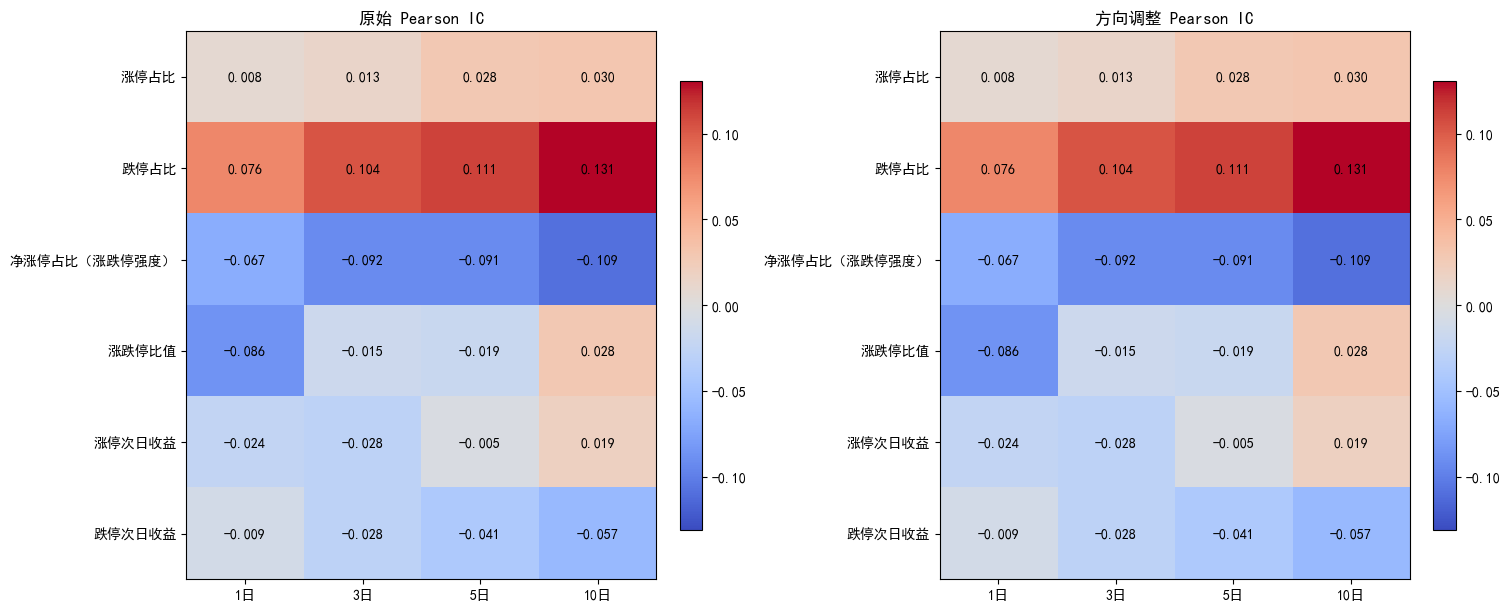

In [41]:
# ============================================================
# 执行 IC 分析：计算全样本 IC 并展示汇总表和热力图
# ============================================================

# 计算六个因子 × 四个周期的 Pearson/Spearman IC
ic_summary = analyze_ic(research_data)
# 展示汇总数字表 + 原始 IC / 方向调整 IC 热力图
report_ic_summary(ic_summary)

In [42]:
# ============================================================
# 滚动 IC 计算：50日/100日窗口的滚动 Pearson IC
# ============================================================

# 1. 计算 6因子 × 4周期 × 2窗口 的滚动 IC 序列
rolling_ic_detail = compute_rolling_ic(research_data)

# 2. 提取当前最新（最后一个可用日期）的滚动 IC 值，与全样本 IC 对比
rolling_ic_summary = (
    rolling_ic_detail.dropna(subset=["available_date", "rolling_ic"])
    .sort_values("available_date")
    .groupby(["factor", "factor_label", "horizon", "window"], as_index=False)
    .agg(
        latest_available_date=("available_date", "last"),
        latest_rolling_ic=("rolling_ic", "last"),
        latest_rolling_n_obs=("rolling_n_obs", "last"),
    )
)

# 3. 构造对比表：全样本 IC vs 最新 50日/100日 滚动 IC
full_sample = ic_summary[["factor", "factor_label", "horizon", "pearson_ic"]]
rolling_display = full_sample.copy()
display_columns = ["factor_label", "horizon", "pearson_ic"]
display_renames = {
    "factor_label": "因子",
    "horizon": "未来日数",
    "pearson_ic": "全样本 IC",
}
display_formats = {"全样本 IC": "{:+.4f}"}

# 按 ROLLING_IC_WINDOWS 配置动态生成各窗口的汇总列
for window in ROLLING_IC_WINDOWS:
    ic_column = f"latest_{window}d_ic"
    count_column = f"latest_{window}d_n_obs"
    date_column = f"latest_{window}d_available_date"
    window_summary = rolling_ic_summary.loc[
        rolling_ic_summary["window"] == window,
        [
            "factor", "horizon", "latest_rolling_ic",
            "latest_rolling_n_obs", "latest_available_date",
        ],
    ].rename(
        columns={
            "latest_rolling_ic": ic_column,
            "latest_rolling_n_obs": count_column,
            "latest_available_date": date_column,
        }
    )
    rolling_display = rolling_display.merge(
        window_summary, on=["factor", "horizon"], how="left"
    )
    display_columns.extend([ic_column, count_column, date_column])
    display_renames.update(
        {
            ic_column: f"最新 {window} 日 IC",
            count_column: f"{window} 日有效样本",
            date_column: f"{window} 日最新可用日",
        }
    )
    display_formats.update(
        {
            f"最新 {window} 日 IC": "{:+.4f}",
            f"{window} 日最新可用日": format_optional_date,
        }
    )

rolling_display = rolling_display[display_columns].rename(columns=display_renames)
display(rolling_display.style.format(display_formats))

,因子,未来日数,全样本 IC,最新 50 日 IC,50 日有效样本,50 日最新可用日,最新 100 日 IC,100 日有效样本,100 日最新可用日
0,涨停占比,1,+0.0080,-0.0015,50,2026-07-20,-0.0704,100,2026-07-20
1,涨停占比,3,+0.0133,+0.0669,50,2026-07-20,-0.0926,100,2026-07-20
2,涨停占比,5,+0.0279,-0.1106,50,2026-07-20,-0.1651,100,2026-07-20
3,涨停占比,10,+0.0298,-0.6535,50,2026-07-20,-0.4196,100,2026-07-20
4,跌停占比,1,+0.0756,-0.0984,50,2026-07-20,-0.0597,100,2026-07-20
5,跌停占比,3,+0.1042,-0.3750,50,2026-07-20,-0.1972,100,2026-07-20
6,跌停占比,5,+0.1115,-0.2085,50,2026-07-20,-0.1304,100,2026-07-20
7,跌停占比,10,+0.1308,-0.1493,50,2026-07-20,+0.0031,100,2026-07-20
8,净涨停占比（涨跌停强度）,1,-0.0673,+0.0543,50,2026-07-20,-0.0201,100,2026-07-20
9,净涨停占比（涨跌停强度）,3,-0.0916,+0.2313,50,2026-07-20,+0.0187,100,2026-07-20


### 2.1 IC 历史走势

- 滚动窗口由 `ROLLING_IC_WINDOWS` 统一配置；短窗口更灵敏，长窗口更平滑。
- 横轴使用未来收益完全兑现后的**可用日期**，避免把尚未发生的收益提前到因子日期。
- 绿色虚线是对应因子和周期的全样本 IC，灰色区域为 `±0.02` 的方向中性区间。
- 右轴虚线圆点为非重叠区块 IC 的累计和；相邻累计点不共享因子窗口。
- 每个因子单独展示一张 2×2 图，对应未来 1、3、5、10 日四个研究周期。


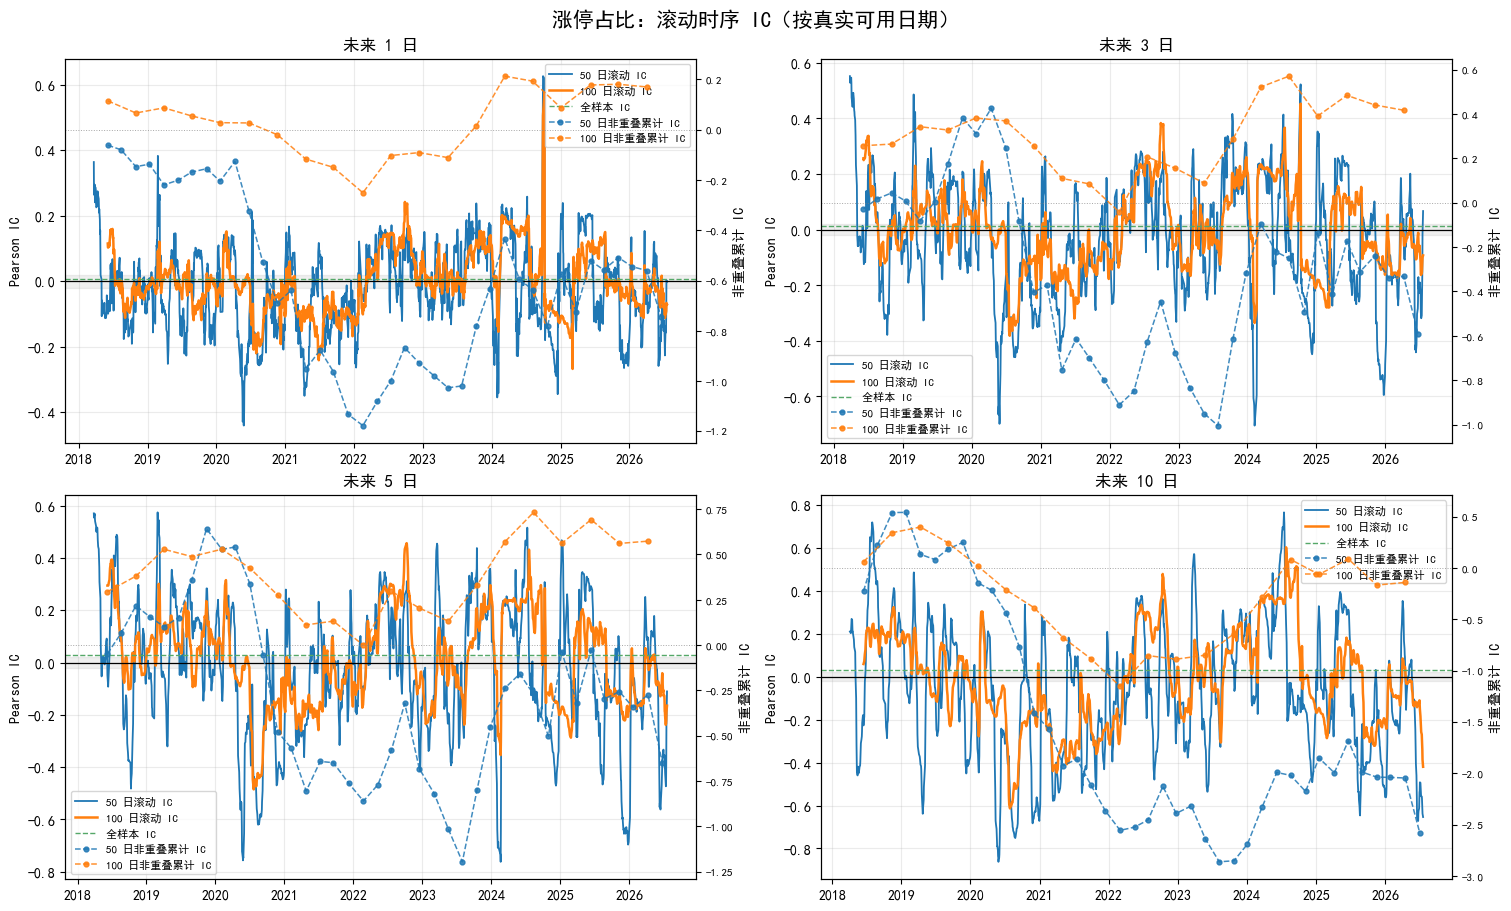

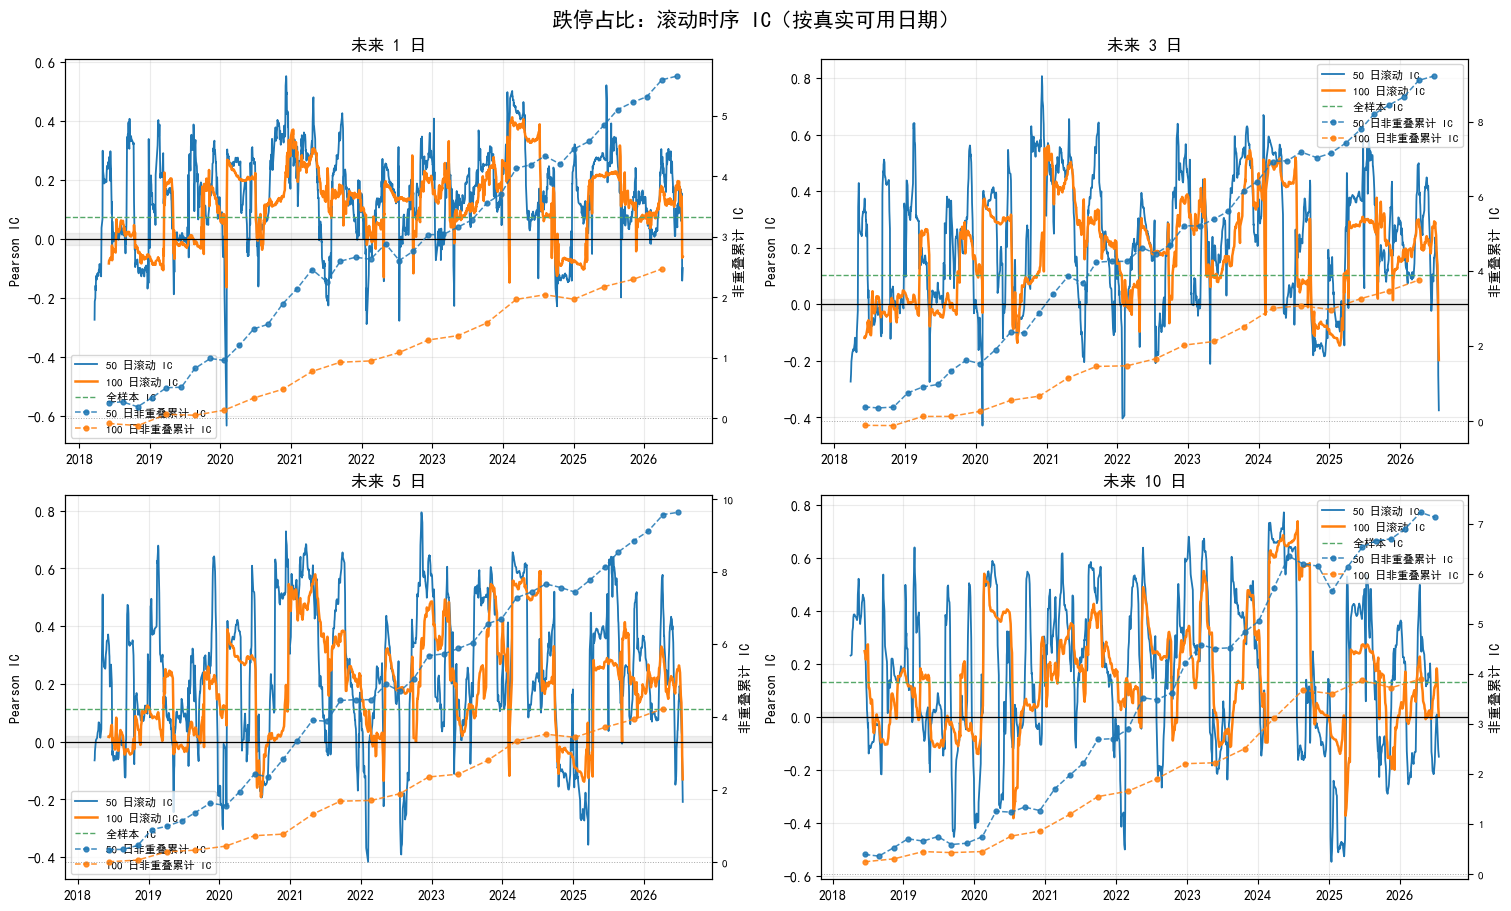

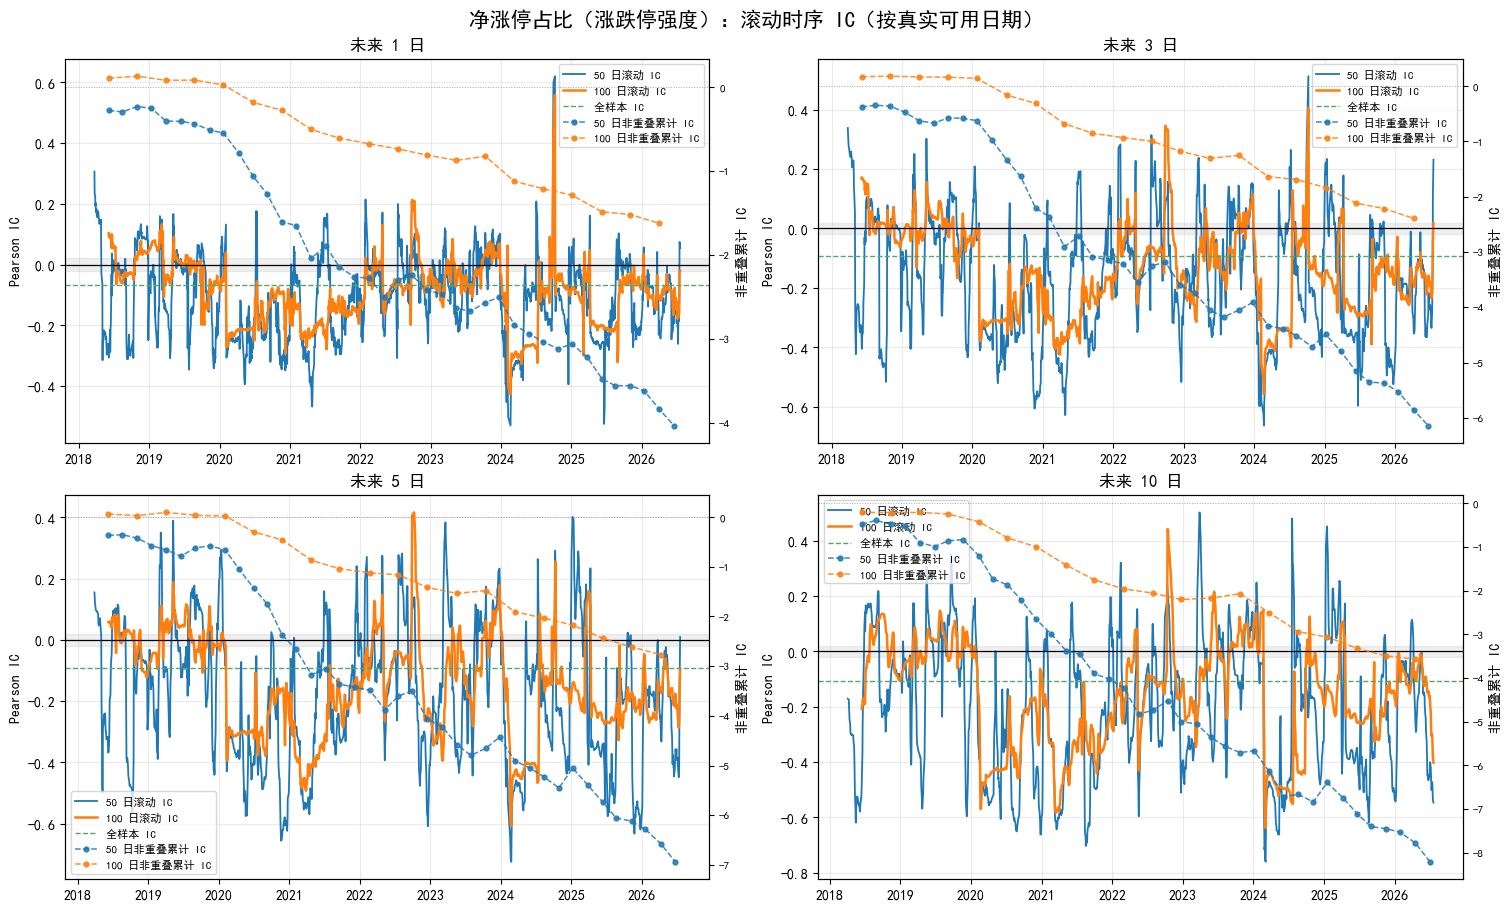

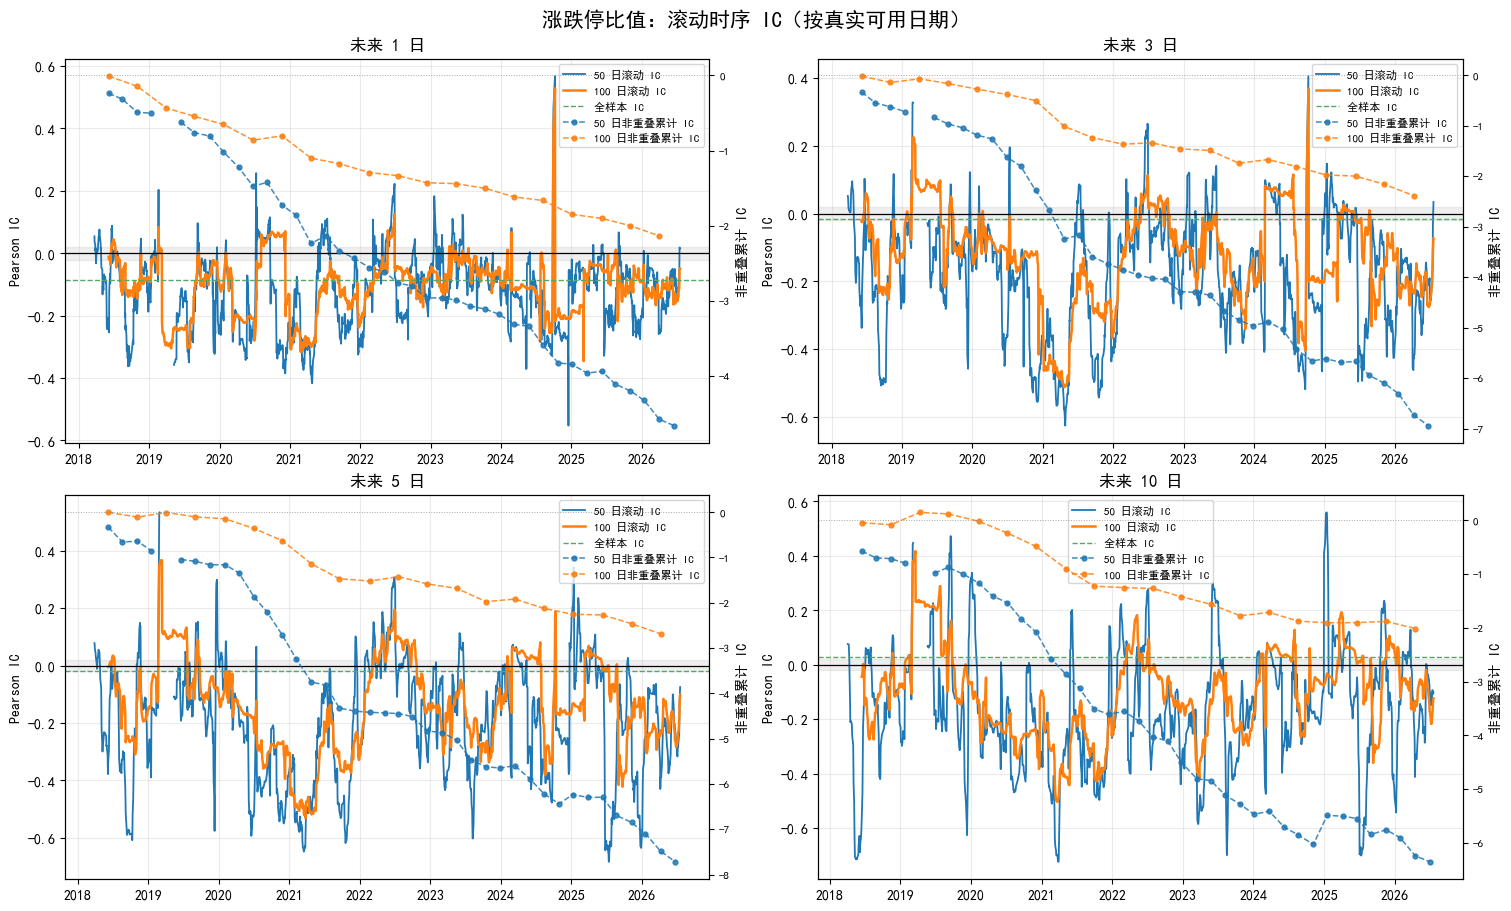

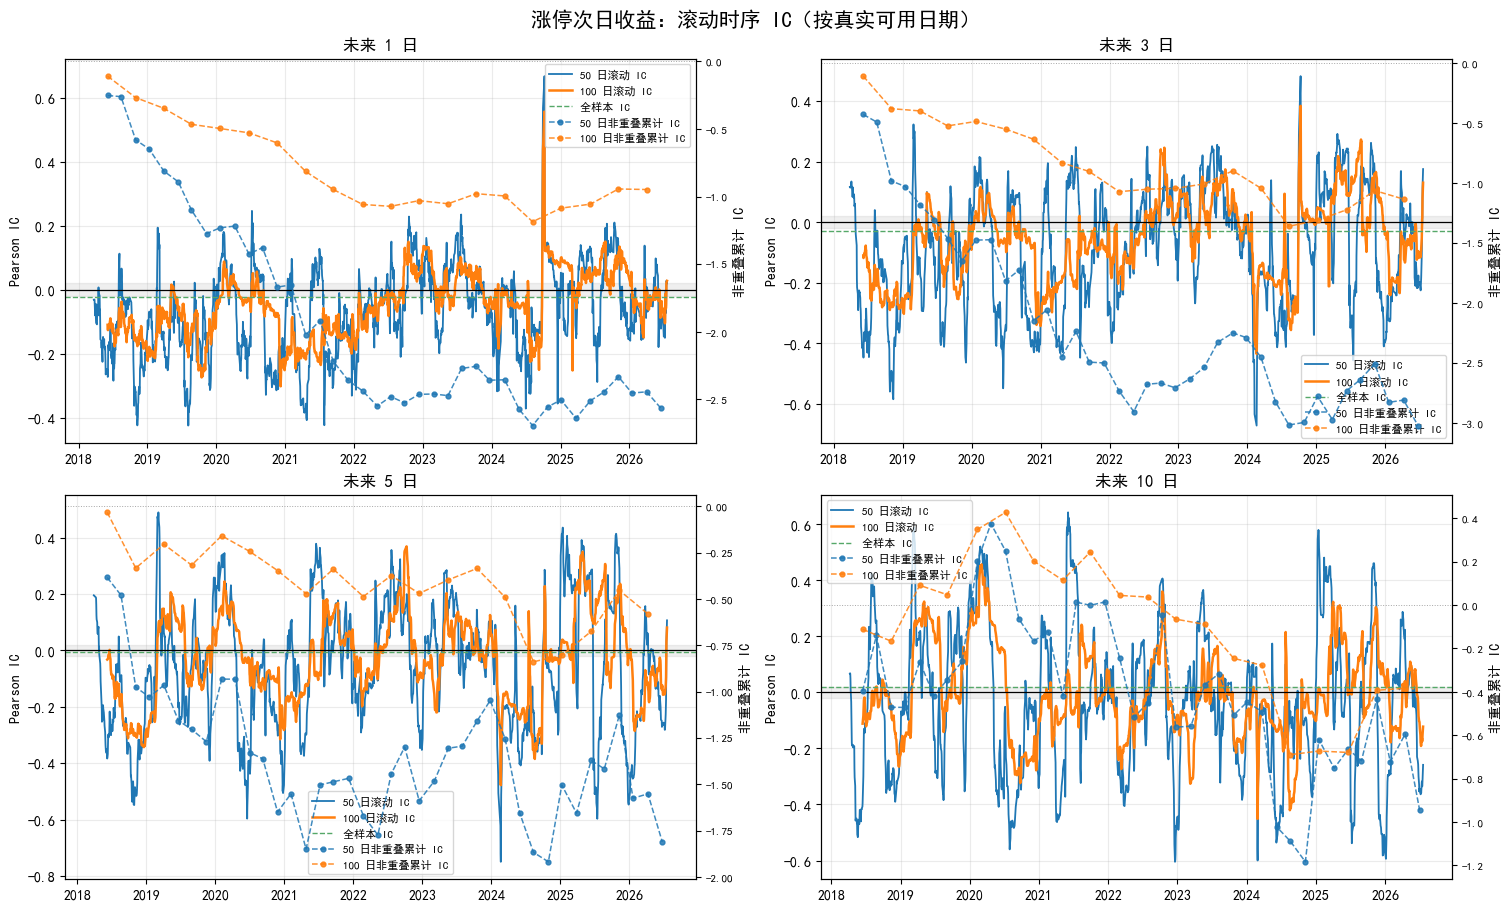

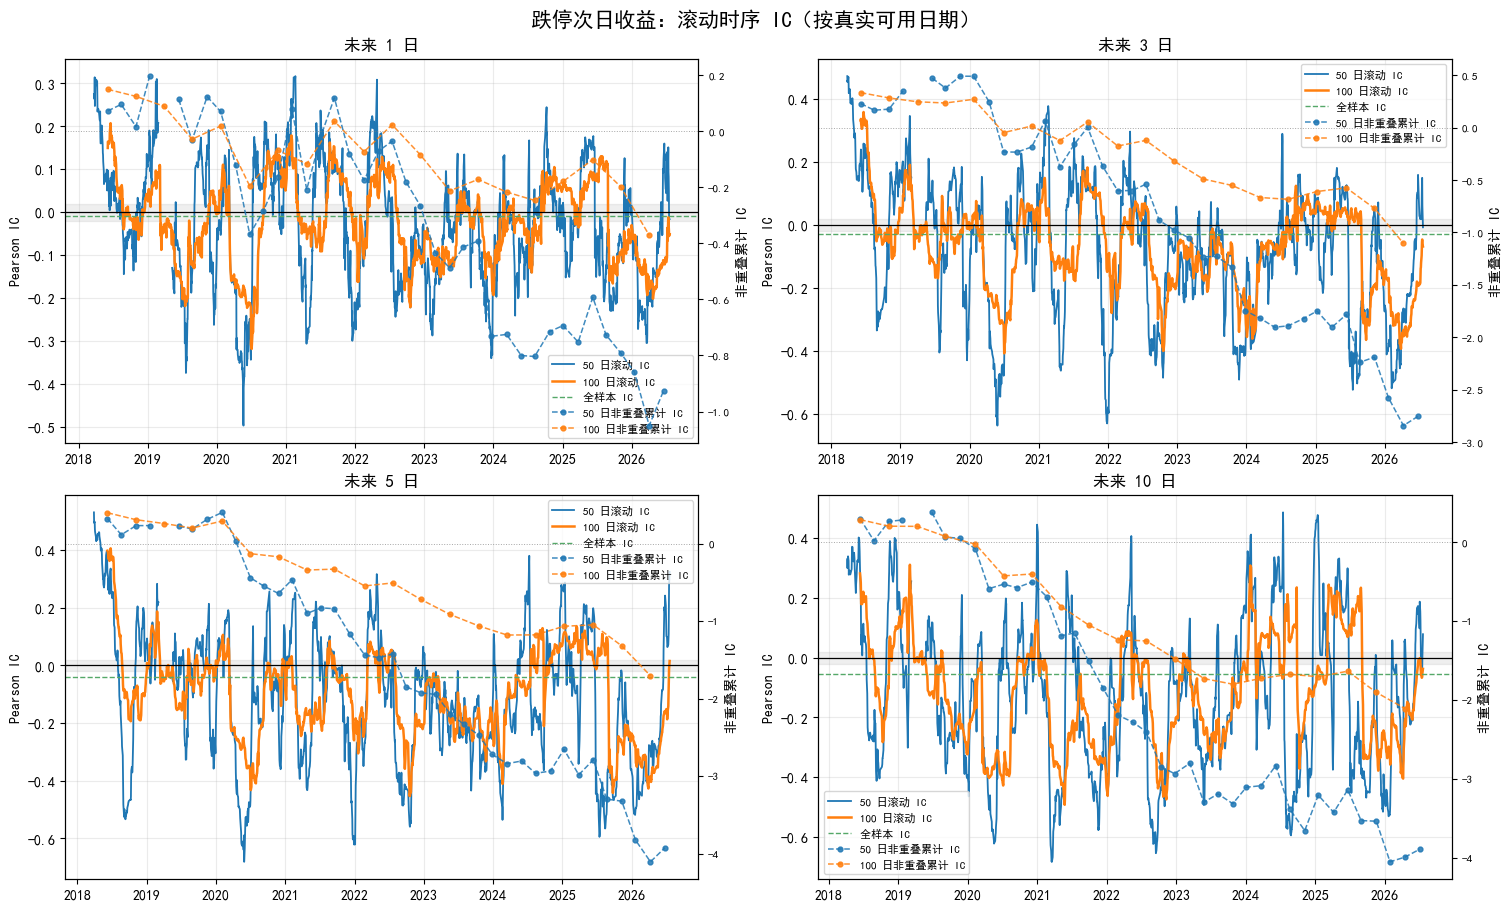

In [43]:
# ============================================================
# build_non_overlapping_cumulative_ic：从滚动 IC 抽取非重叠区块
# ============================================================
def build_non_overlapping_cumulative_ic(
    series: pd.DataFrame,
    window: int,
) -> pd.DataFrame:
    """
    从滚动 IC 序列抽取互不重叠窗口，并计算区块 IC 累计和。

    第一个区块覆盖第 1～window 个交易日，之后每隔 window 个交易日
    取一次滚动 IC；因此相邻累计点使用的因子窗口没有交集。
    这避免了滚动 IC 中相邻窗口高度重叠带来的视觉平滑假象。

    Parameters
    ----------
    series : pd.DataFrame
        单条滚动 IC 序列（已按 factor_window_end_date 排序）。
    window : int
        抽取步长（与滚动窗口大小一致）。

    Returns
    -------
    pd.DataFrame
        含 block_ic（非重叠区块 IC）和 cumulative_ic（累计和）的抽样结果。
    """
    if window <= 0:
        raise ValueError("window 必须是正整数")

    ordered = series.sort_values("factor_window_end_date").reset_index(drop=True)
    # 每隔 window 个交易日取一个点
    endpoints = ordered.iloc[window - 1 :: window].copy()
    endpoints = endpoints.dropna(subset=["available_date"]).rename(
        columns={"rolling_ic": "block_ic"}
    )
    endpoints["cumulative_ic"] = endpoints["block_ic"].cumsum()
    return endpoints


# ============================================================
# plot_rolling_ic_history：逐因子绘制四个周期的滚动 IC 历史走势
# ============================================================
def plot_rolling_ic_history(
    rolling_detail: pd.DataFrame,
    full_ic_summary: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    horizons: tuple[int, ...] = HORIZONS,
    windows: tuple[int, ...] = ROLLING_IC_WINDOWS,
    neutral_band: float = IC_NEUTRAL_BAND,
) -> None:
    """
    逐因子绘制四个未来周期的滚动 IC 历史走势。

    每张图包含四个周期子图（1/3/5/10 日）；左轴展示当前配置窗口的滚动 IC、
    零轴和全样本 IC 参考线以及 ±0.02 中性区间，右轴展示非重叠区块 IC 累计和。
    横轴固定使用 available_date，确保图中每个点只在未来收益已经完整兑现后出现。

    Parameters
    ----------
    rolling_detail : pd.DataFrame
        compute_rolling_ic 的输出，长格式 IC 序列。
    full_ic_summary : pd.DataFrame
        analyze_ic 的输出，用于在全样本 IC 参考线。
    factor_columns : list[str]
        因子列名列表。
    horizons : tuple[int, ...]
        未来收益周期列表。
    windows : tuple[int, ...]
        滚动窗口列表。
    neutral_band : float
        IC 中性区间半宽（默认 ±0.02）。
    """
    # 构建全样本 IC 查询表：(因子, 周期) → Pearson IC
    full_ic_lookup = full_ic_summary.set_index(["factor", "horizon"])["pearson_ic"]
    # 给每个窗口分配一个颜色
    colors = {window: f"C{index}" for index, window in enumerate(windows)}

    for factor in factor_columns:
        fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
        for axis, horizon in zip(axes.ravel(), horizons):
            # 创建右轴（非重叠累计 IC）
            cumulative_axis = axis.twinx()
            
            for window in windows:
                color = colors[window]
                # 提取当前(因子, 周期, 窗口)的 IC 序列
                series = rolling_detail[
                    (rolling_detail["factor"] == factor)
                    & (rolling_detail["horizon"] == horizon)
                    & (rolling_detail["window"] == window)
                ].sort_values("factor_window_end_date")
                # 过滤尚未兑现的日期（available_date 为空），保留 IC 的 NaN
                rolling_series = series.dropna(subset=["available_date"])
                
                # 左轴：滚动 IC 曲线
                axis.plot(
                    rolling_series["available_date"],
                    rolling_series["rolling_ic"],
                    label=f"{window} 日滚动 IC",
                    color=color,
                    linewidth=1.3 if window == min(windows) else 1.8,
                )
                
                # 右轴：非重叠区块累计 IC（点线图）
                cumulative = build_non_overlapping_cumulative_ic(series, window)
                cumulative_axis.plot(
                    cumulative["available_date"],
                    cumulative["cumulative_ic"],
                    label=f"{window} 日非重叠累计 IC",
                    color=color,
                    linestyle="--",
                    marker="o",
                    markersize=3.5,
                    linewidth=1.1,
                    alpha=0.85,
                )

            # 参考线：零轴、中性区间、全样本 IC
            axis.axhline(0, color="black", linewidth=0.9)
            axis.axhspan(-neutral_band, neutral_band, color="grey", alpha=0.12)
            axis.axhline(
                full_ic_lookup.loc[(factor, horizon)],
                color="#55A868",
                linestyle="--",
                linewidth=1.0,
                label="全样本 IC",
            )
            
            axis.set_title(f"未来 {horizon} 日")
            axis.set_ylabel("Pearson IC")
            cumulative_axis.set_ylabel("非重叠累计 IC")
            cumulative_axis.axhline(
                0, color="grey", linestyle=":", linewidth=0.7, alpha=0.7
            )
            cumulative_axis.tick_params(axis="y", labelsize=8)
            axis.grid(alpha=0.25)
            
            # 合并左右轴的图例
            left_handles, left_labels = axis.get_legend_handles_labels()
            right_handles, right_labels = cumulative_axis.get_legend_handles_labels()
            axis.legend(
                left_handles + right_handles,
                left_labels + right_labels,
                fontsize=8,
            )

        fig.suptitle(
            f"{FACTOR_LABELS[factor]}：滚动时序 IC（按真实可用日期）",
            fontsize=15,
        )
        plt.show()


# ============================================================
# 执行：绘制所有因子的滚动 IC 历史走势
# ============================================================
plot_rolling_ic_history(rolling_ic_detail, ic_summary)

In [44]:
# ============================================================
# 结论汇总：IC 表现 vs 择时表现的交叉对比表
# ============================================================

# 将 IC 均值与择时绩效合并，观察因子预测力与真实择时收益之间的关系
conclusion_table = (
    ic_summary.groupby(["factor", "factor_label"], as_index=False)
    .agg(平均原始IC=("pearson_ic", "mean"), 平均方向调整IC=("directional_pearson_ic", "mean"))
    .merge(
        timing_summary.groupby(["factor", "factor_label"], as_index=False)
        .agg(
            平均年化差=("annual_excess_return", "mean"),
            平均相对期末净值=("relative_final_nav", "mean"),
            跑赢基准周期数=("relative_final_nav", lambda values: int((values > 0).sum())),
        ),
        on=["factor", "factor_label"],
        how="left",
    )
    .rename(columns={"factor_label": "因子"})
)
display(
    conclusion_table[
        [
            "因子", "平均原始IC", "平均方向调整IC", "平均年化差",
            "平均相对期末净值", "跑赢基准周期数",
        ]
    ].style.format(
        {
            "平均原始IC": "{:.4f}",
            "平均方向调整IC": "{:.4f}",
            "平均年化差": "{:+.2%}",
            "平均相对期末净值": "{:+.2%}",
        }
    )
)

,因子,平均原始IC,平均方向调整IC,平均年化差,平均相对期末净值,跑赢基准周期数
0,跌停次日收益,-0.0337,-0.0337,-3.31%,-16.77%,1
1,跌停占比,0.1055,0.1055,+0.30%,+3.02%,3
2,涨跌停比值,-0.0229,-0.0229,-7.12%,-36.93%,0
3,涨停次日收益,-0.0095,-0.0095,-2.92%,-15.95%,1
4,涨停占比,0.0198,0.0198,-0.58%,-3.47%,1
5,净涨停占比（涨跌停强度）,-0.0897,-0.0897,-2.25%,-12.70%,1
